# Análisis de Evaluación de Sistemas de Recomendación

Este notebook analiza los resultados de la evaluación offline de diferentes estrategias de recomendación usando múltiples métricas.

## Métricas evaluadas:
- **NDCG@9**: Normalized Discounted Cumulative Gain
- **Precision@9**: Proporción de recomendaciones relevantes
- **Recall@9**: Proporción de items relevantes recuperados
- **F1@9**: Media armónica de Precision y Recall
- **MRR**: Mean Reciprocal Rank (posición del primer item relevante)
- **Genre Diversity**: Diversidad de géneros en las recomendaciones
- **Artist Diversity**: Diversidad de artistas en las recomendaciones
- **Novelty**: Novedad basada en popularidad (-log2)

## Estrategias evaluadas:
- **max_ensemble**: Sistema Max-Ensemble (toma el score máximo de cada estrategia)
- **rrf_ensemble**: Reciprocal Rank Fusion (combina rankings por consenso)
- **hybrid**: Sistema híbrido tradicional (baseline de comparación)
- **advanced**: Recomendaciones avanzadas (NMF + Two Towers combinados)
- **nmf**: Factorización matricial (NMF)
- **two_towers**: Two Towers (Deep Learning)
- **pairs**: Co-ocurrencia (release_pairs)
- **content**: Perfiles de contenido
- **random**: Exploración aleatoria (baseline)
- **popular**: Popularidad (baseline)

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


# Configurar estilo
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11

# Cargar datos
csv_path = Path("../offline_recommender/output/rrf_vs_max.csv")
df = pd.read_csv(csv_path)

print(f"📊 Datos cargados: {len(df)} usuarios evaluados")
print(f"📈 Columnas: {len(df.columns)}")
print("\nPrimeras filas:")
df.head()

📊 Datos cargados: 1675 usuarios evaluados
📈 Columnas: 82

Primeras filas:


,user_id,holdout_size,hybrid_ndcg,hybrid_precision,hybrid_recall,hybrid_f1,hybrid_mrr,hybrid_genre_diversity,hybrid_artist_diversity,hybrid_novelty,...,random_artist_diversity,random_novelty,popular_ndcg,popular_precision,popular_recall,popular_f1,popular_mrr,popular_genre_diversity,popular_artist_diversity,popular_novelty
0,februarystars57,8,0.000000,0.000000,0.000000,0.000000,0.0,0.555556,0.222222,1.560719,...,1.0,11.255723,1.0,0.111111,0.125,0.117647,1.0,1.444444,0.666667,0.314409
1,untitled1,9,0.000000,0.000000,0.000000,0.000000,0.0,1.777778,0.888889,2.462058,...,1.0,11.830108,0.0,0.000000,0.000,0.000000,0.0,1.111111,0.444444,0.252914
2,Thomthumb,16,0.000000,0.000000,0.000000,0.000000,0.0,0.777778,0.333333,1.760441,...,1.0,12.552120,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.224018
3,Arayhenry81,10,0.000000,0.000000,0.000000,0.000000,0.0,1.111111,0.888889,3.420546,...,1.0,11.891331,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.224018
4,silvermetal007,17,0.967468,0.333333,0.176471,0.230769,1.0,0.888889,0.555556,0.909647,...,1.0,12.742810,0.0,0.000000,0.000,0.000000,0.0,1.333333,0.555556,0.290052


In [16]:
# Definir estrategias y métricas
strategies = [
    "max_ensemble",
    "rrf_ensemble",
    "hybrid",
    "advanced",
    "nmf",
    "two_towers",
    "pairs",
    "content",
    "random",
    "popular",
]
metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]

# Calcular estadísticas descriptivas por estrategia y métrica
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA")
print("=" * 80)

for strategy in strategies:
    print(f"\n{strategy.upper()}:")
    print("-" * 40)
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            values = df[col].dropna()
            if len(values) > 0:
                print(
                    f"  {metric:20s}: mean={values.mean():.4f}  std={values.std():.4f}  min={values.min():.4f}  max={values.max():.4f}"
                )

ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA

MAX_ENSEMBLE:
----------------------------------------
  ndcg                : mean=0.5528  std=0.3516  min=0.0000  max=1.0000
  precision           : mean=0.2013  std=0.1844  min=0.0000  max=1.0000
  recall              : mean=0.0682  std=0.0718  min=0.0000  max=0.5000
  f1                  : mean=0.0865  std=0.0787  min=0.0000  max=0.4667
  mrr                 : mean=0.4918  std=0.3935  min=0.0000  max=1.0000
  genre_diversity     : mean=1.7906  std=0.2821  min=0.8889  max=2.5556
  artist_diversity    : mean=0.9997  std=0.0109  min=0.5556  max=1.0000
  novelty             : mean=1.1363  std=0.5550  min=0.2240  max=4.1251

RRF_ENSEMBLE:
----------------------------------------
  ndcg                : mean=0.5692  std=0.3699  min=0.0000  max=1.0000
  precision           : mean=0.1976  std=0.1845  min=0.0000  max=1.0000
  recall              : mean=0.0671  std=0.0738  min=0.0000  max=0.5000
  f1                  : mean=0.0848  std=0.0796  min=0.

In [17]:
# Crear DataFrame con promedios por estrategia
summary_data = []
for strategy in strategies:
    row = {"strategy": strategy}
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
        else:
            row[metric] = 0.0
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index("strategy")

print("=" * 80)
print("PROMEDIOS POR ESTRATEGIA")
print("=" * 80)
print(summary_df.round(4))

PROMEDIOS POR ESTRATEGIA
                ndcg  precision  recall      f1     mrr  genre_diversity  \
strategy                                                                   
max_ensemble  0.5528     0.2013  0.0682  0.0865  0.4918           1.7906   
rrf_ensemble  0.5692     0.1976  0.0671  0.0848  0.5350           1.6648   
hybrid        0.3417     0.1287  0.0388  0.0495  0.3028           1.1133   
advanced      0.3204     0.1241  0.0334  0.0445  0.2786           1.0887   
nmf           0.2136     0.0725  0.0240  0.0309  0.1810           0.9455   
two_towers    0.2950     0.1163  0.0302  0.0403  0.2483           1.1563   
pairs         0.5408     0.1901  0.0625  0.0796  0.5177           1.3292   
content       0.3785     0.0998  0.0482  0.0562  0.3561           0.4281   
random        0.0004     0.0001  0.0000  0.0000  0.0002           1.7516   
popular       0.2075     0.0732  0.0188  0.0250  0.1673           1.3062   

              artist_diversity  novelty  
strategy            

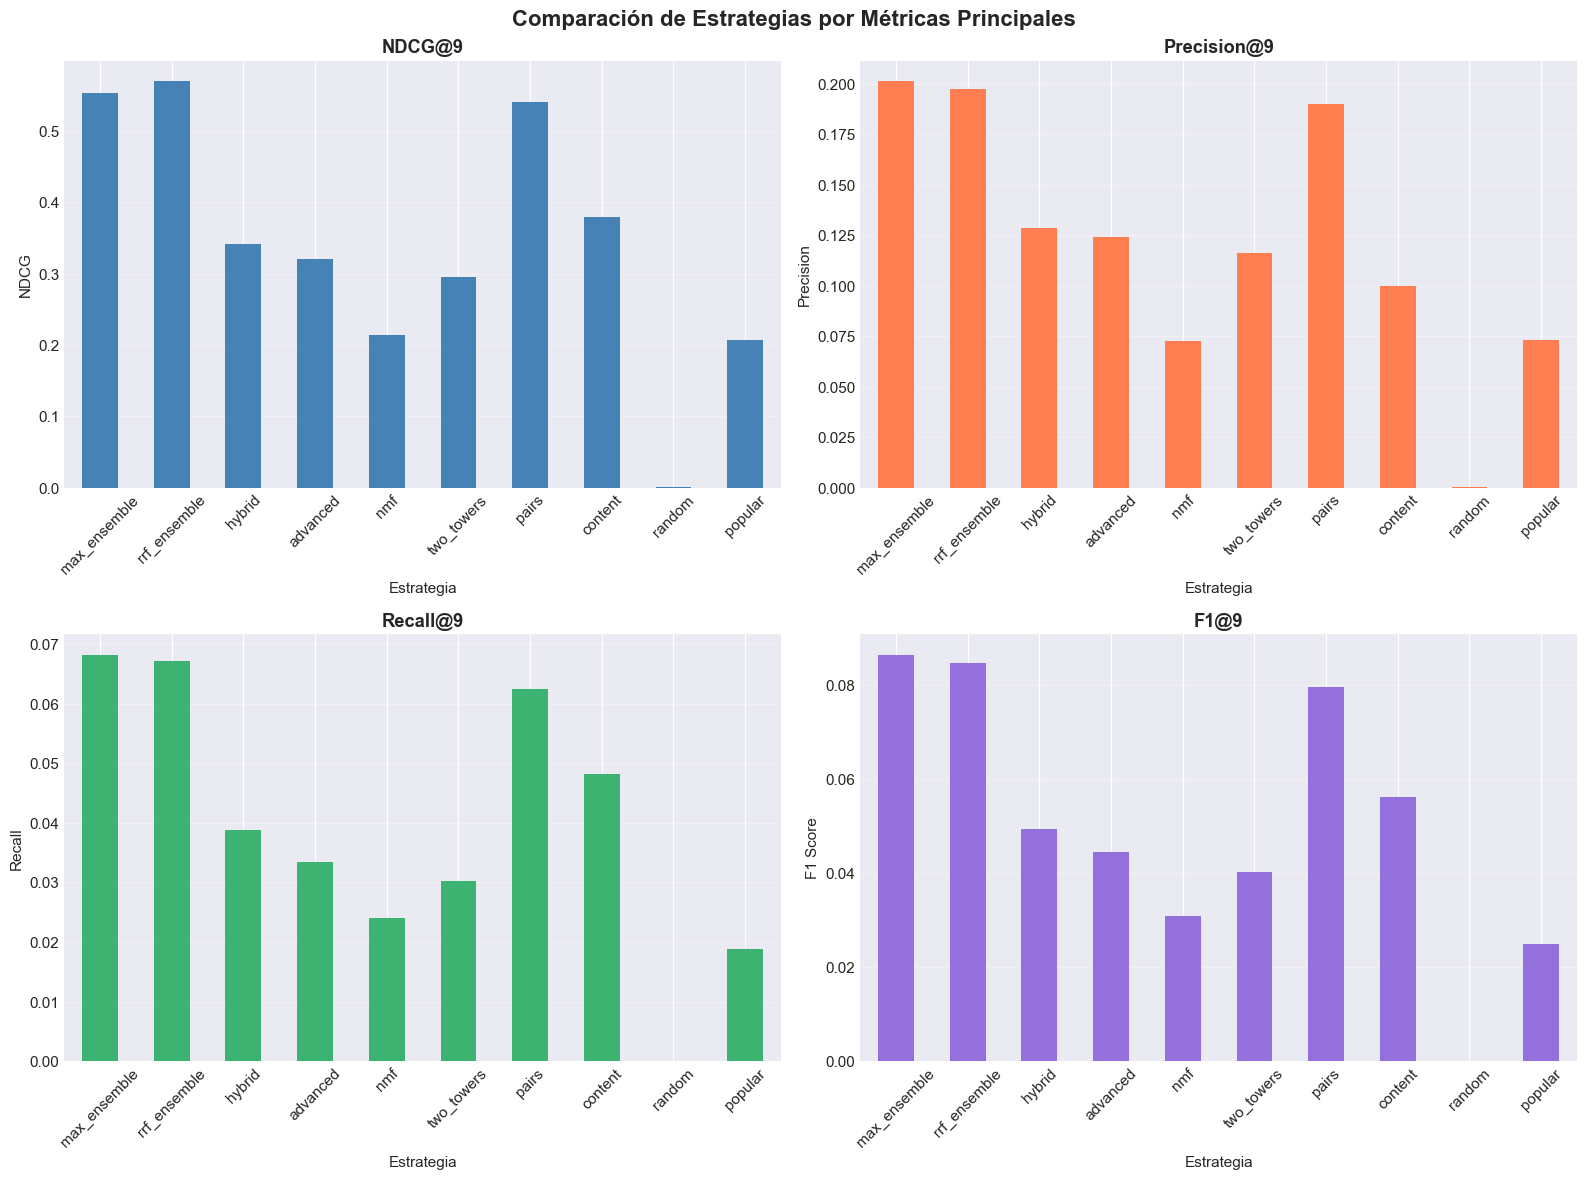

In [18]:
# Visualización 1: Comparación de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparación de Estrategias por Métricas Principales", fontsize=16, fontweight="bold")

# NDCG
ax1 = axes[0, 0]
summary_df["ndcg"].plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("NDCG@9", fontweight="bold")
ax1.set_ylabel("NDCG")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Precision
ax2 = axes[0, 1]
summary_df["precision"].plot(kind="bar", ax=ax2, color="coral")
ax2.set_title("Precision@9", fontweight="bold")
ax2.set_ylabel("Precision")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Recall
ax3 = axes[1, 0]
summary_df["recall"].plot(kind="bar", ax=ax3, color="mediumseagreen")
ax3.set_title("Recall@9", fontweight="bold")
ax3.set_ylabel("Recall")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

# F1
ax4 = axes[1, 1]
summary_df["f1"].plot(kind="bar", ax=ax4, color="mediumpurple")
ax4.set_title("F1@9", fontweight="bold")
ax4.set_ylabel("F1 Score")
ax4.set_xlabel("Estrategia")
ax4.tick_params(axis="x", rotation=45)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

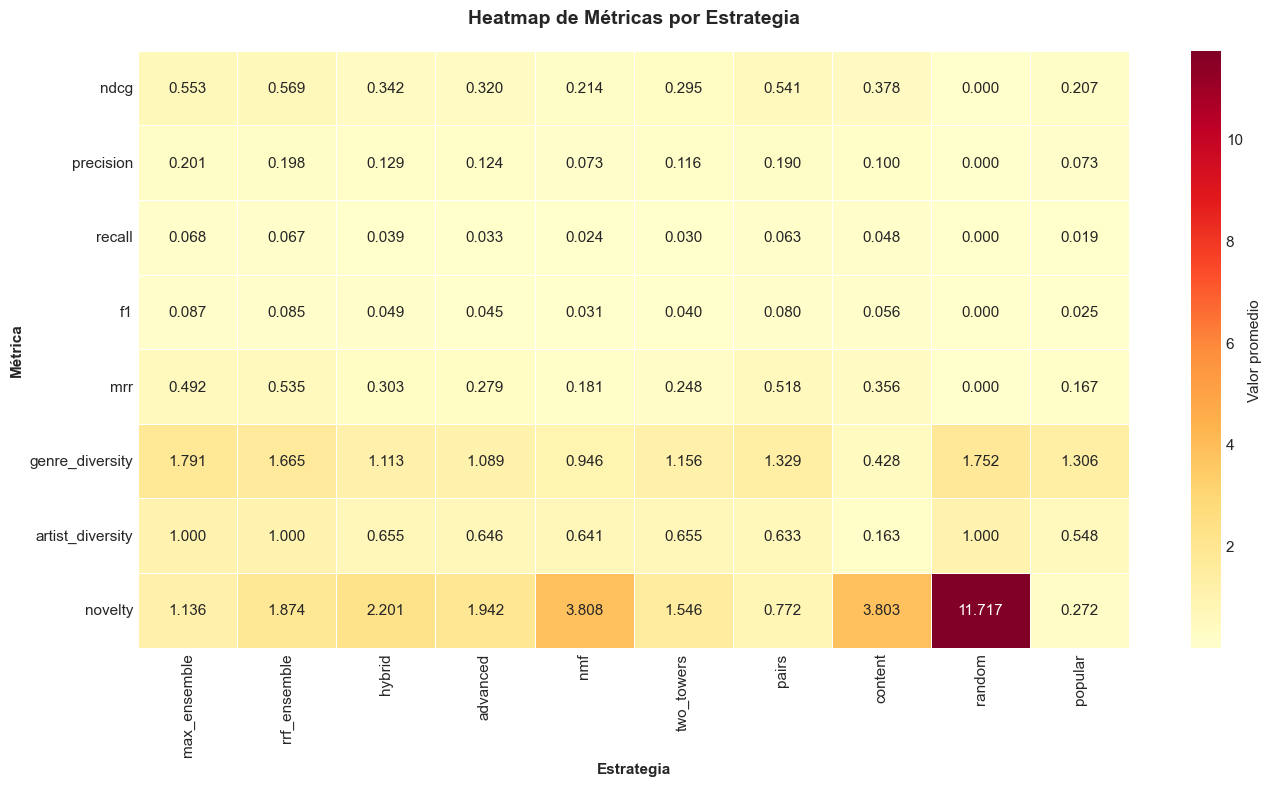

In [19]:
# Visualización 2: Heatmap de todas las métricas
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    summary_df.T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    cbar_kws={"label": "Valor promedio"},
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Heatmap de Métricas por Estrategia", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Estrategia", fontweight="bold")
ax.set_ylabel("Métrica", fontweight="bold")
plt.tight_layout()
plt.show()

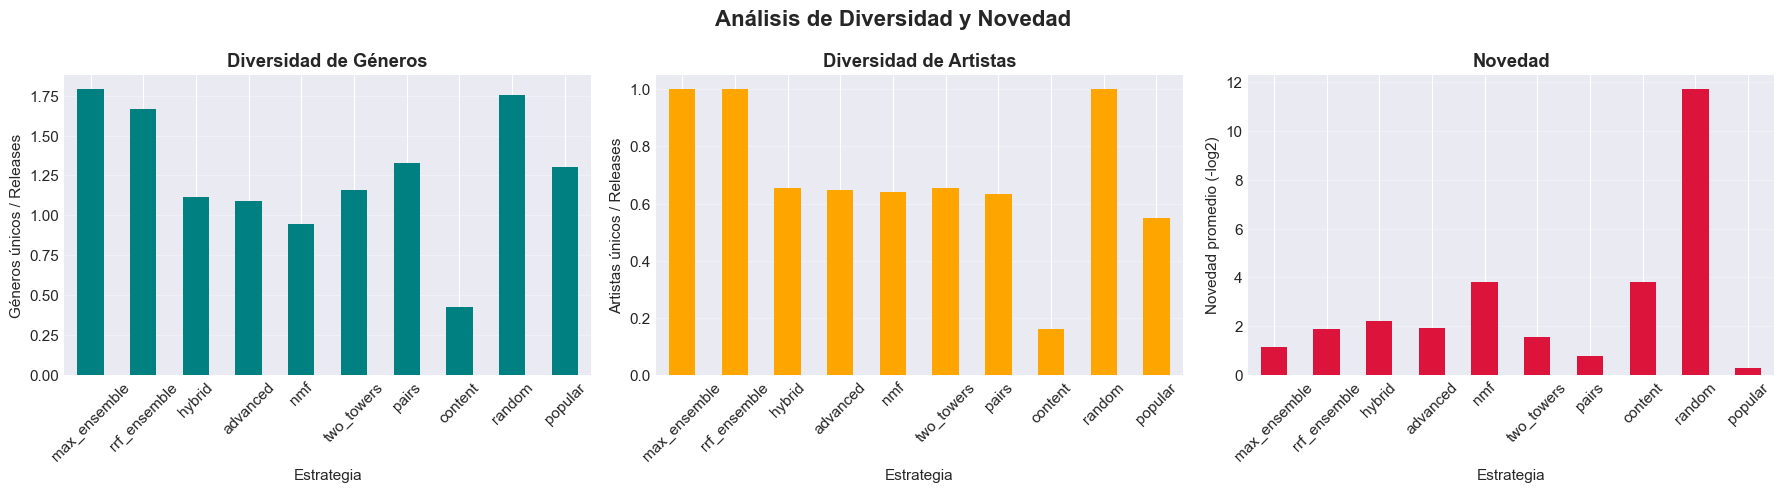

In [20]:
# Visualización 3: Diversidad y Novedad
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Diversidad y Novedad", fontsize=16, fontweight="bold")

# Genre Diversity
ax1 = axes[0]
summary_df["genre_diversity"].plot(kind="bar", ax=ax1, color="teal")
ax1.set_title("Diversidad de Géneros", fontweight="bold")
ax1.set_ylabel("Géneros únicos / Releases")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Artist Diversity
ax2 = axes[1]
summary_df["artist_diversity"].plot(kind="bar", ax=ax2, color="orange")
ax2.set_title("Diversidad de Artistas", fontweight="bold")
ax2.set_ylabel("Artistas únicos / Releases")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Novelty
ax3 = axes[2]
summary_df["novelty"].plot(kind="bar", ax=ax3, color="crimson")
ax3.set_title("Novedad", fontweight="bold")
ax3.set_ylabel("Novedad promedio (-log2)")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_61707/1932012056.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(ndcg_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_61707/1932012056.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(precision_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_61707/1932012056.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(recall_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_61707/1932012056.py:33: M

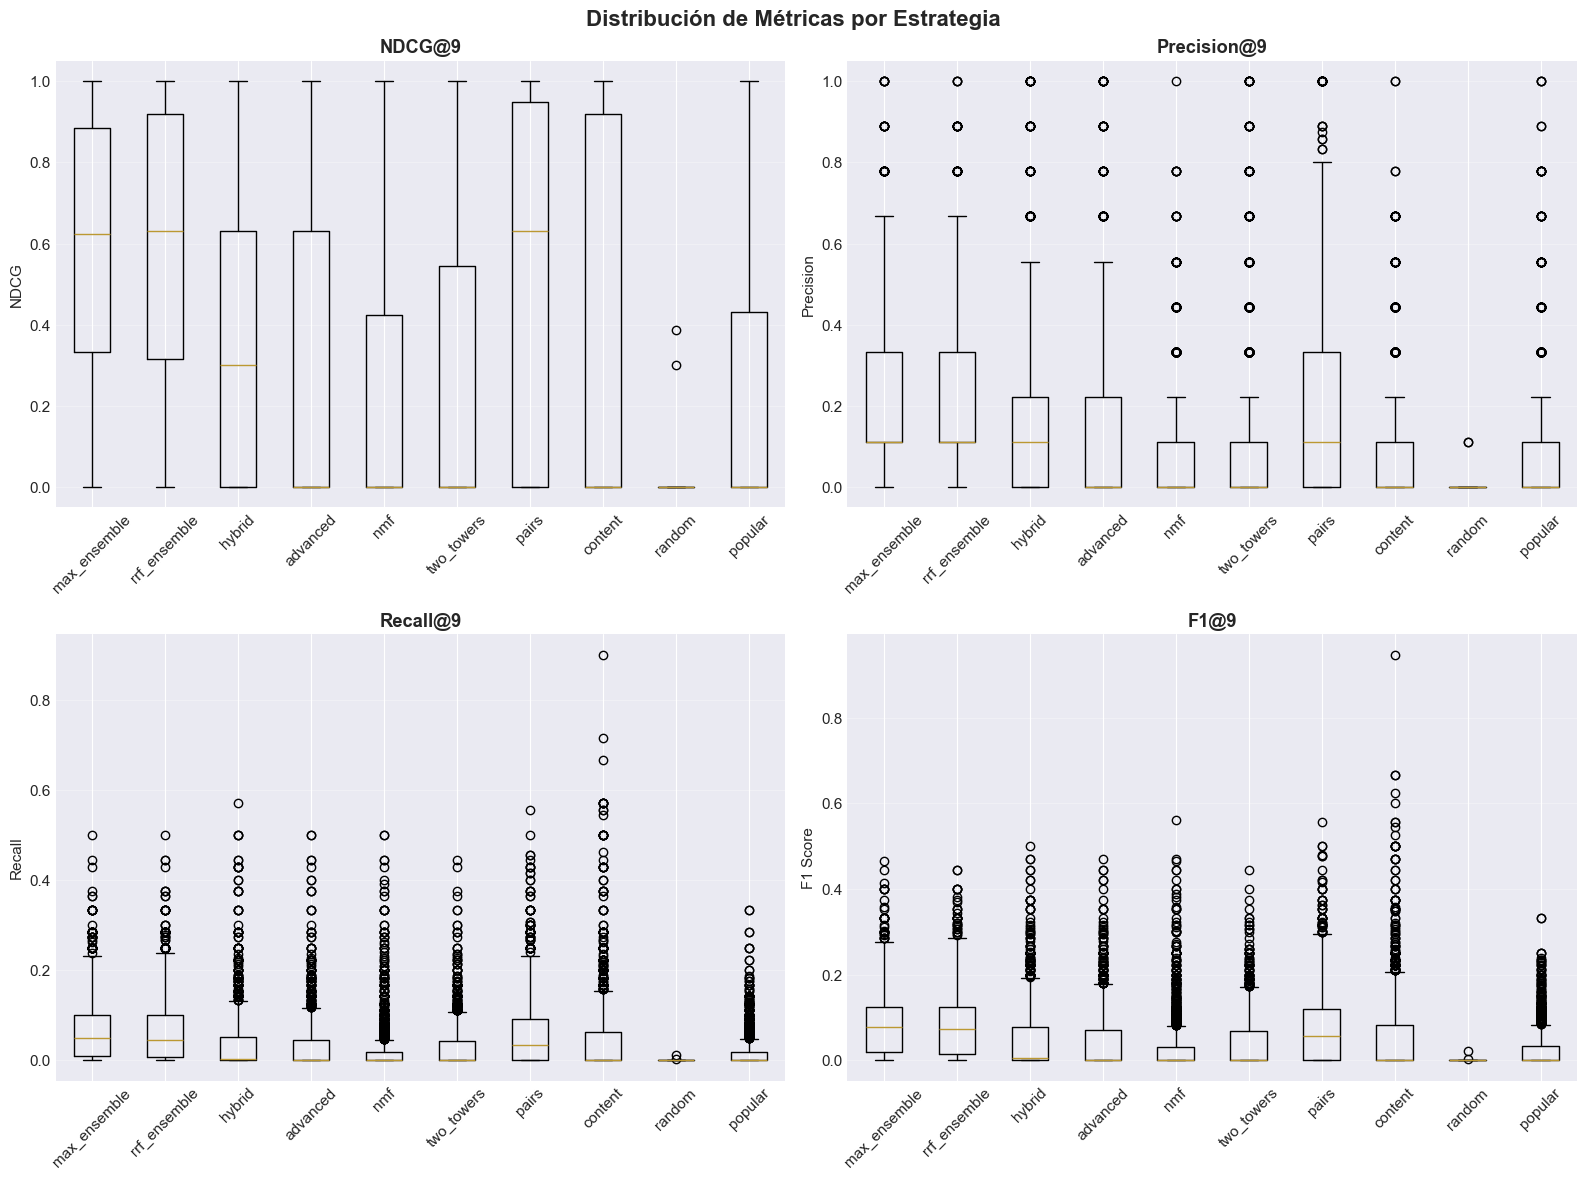

In [21]:
# Visualización 4: Boxplots de distribución de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distribución de Métricas por Estrategia", fontsize=16, fontweight="bold")

# Preparar datos para boxplots
ndcg_data = [df[f"{s}_ndcg"].dropna() for s in strategies]
precision_data = [df[f"{s}_precision"].dropna() for s in strategies]
recall_data = [df[f"{s}_recall"].dropna() for s in strategies]
f1_data = [df[f"{s}_f1"].dropna() for s in strategies]

# NDCG
axes[0, 0].boxplot(ndcg_data, labels=strategies)
axes[0, 0].set_title("NDCG@9", fontweight="bold")
axes[0, 0].set_ylabel("NDCG")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.3)

# Precision
axes[0, 1].boxplot(precision_data, labels=strategies)
axes[0, 1].set_title("Precision@9", fontweight="bold")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(axis="y", alpha=0.3)

# Recall
axes[1, 0].boxplot(recall_data, labels=strategies)
axes[1, 0].set_title("Recall@9", fontweight="bold")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y", alpha=0.3)

# F1
axes[1, 1].boxplot(f1_data, labels=strategies)
axes[1, 1].set_title("F1@9", fontweight="bold")
axes[1, 1].set_ylabel("F1 Score")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Ranking de estrategias por métrica
print("=" * 80)
print("RANKING DE ESTRATEGIAS POR MÉTRICA")
print("=" * 80)

for metric in [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]:
    print(f"\n{metric.upper()}:")
    print("-" * 40)
    ranked = summary_df[metric].sort_values(ascending=False)
    for i, (strategy, value) in enumerate(ranked.items(), 1):
        print(f"  {i}. {strategy:15s}: {value:.4f}")

RANKING DE ESTRATEGIAS POR MÉTRICA

NDCG:
----------------------------------------
  1. rrf_ensemble   : 0.5692
  2. max_ensemble   : 0.5528
  3. pairs          : 0.5408
  4. content        : 0.3785
  5. hybrid         : 0.3417
  6. advanced       : 0.3204
  7. two_towers     : 0.2950
  8. nmf            : 0.2136
  9. popular        : 0.2075
  10. random         : 0.0004

PRECISION:
----------------------------------------
  1. max_ensemble   : 0.2013
  2. rrf_ensemble   : 0.1976
  3. pairs          : 0.1901
  4. hybrid         : 0.1287
  5. advanced       : 0.1241
  6. two_towers     : 0.1163
  7. content        : 0.0998
  8. popular        : 0.0732
  9. nmf            : 0.0725
  10. random         : 0.0001

RECALL:
----------------------------------------
  1. max_ensemble   : 0.0682
  2. rrf_ensemble   : 0.0671
  3. pairs          : 0.0625
  4. content        : 0.0482
  5. hybrid         : 0.0388
  6. advanced       : 0.0334
  7. two_towers     : 0.0302
  8. nmf            : 0.0240


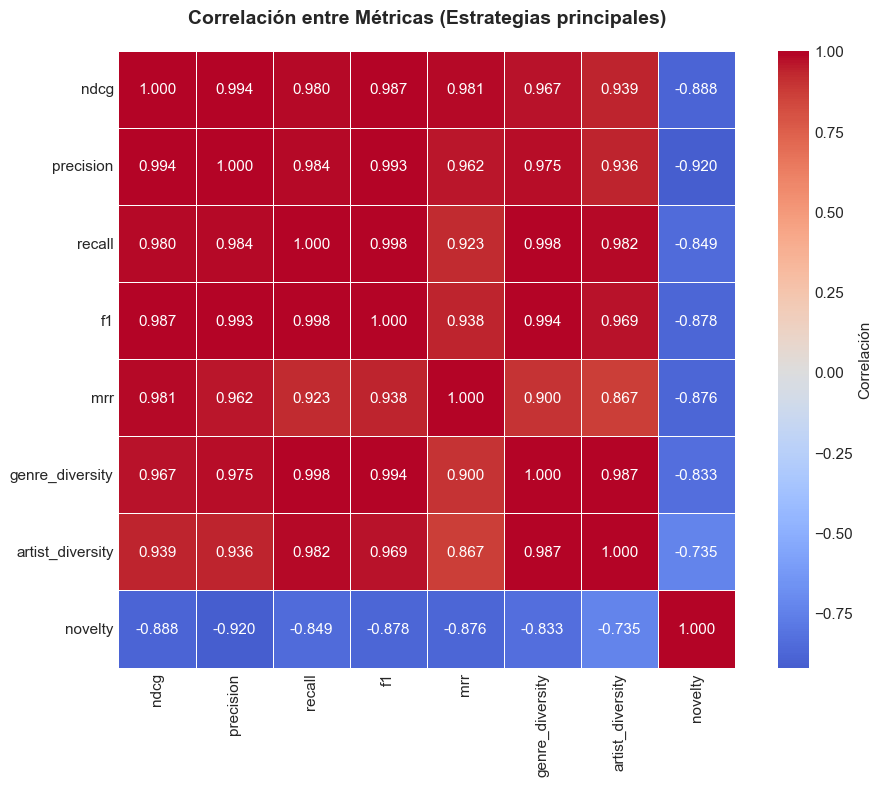

In [23]:
# Análisis de correlación entre métricas (para estrategias principales)
correlation_metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]
corr_data = []

for strategy in ["max_ensemble", "rrf_ensemble", "pairs", "content"]:
    row = {}
    for metric in correlation_metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data, index=["max_ensemble", "rrf_ensemble", "pairs", "content"])

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación"},
    ax=ax,
)
ax.set_title(
    "Correlación entre Métricas (Estrategias principales)", fontsize=14, fontweight="bold", pad=20
)
plt.tight_layout()
plt.show()

In [24]:
# Análisis por tamaño de holdout
df["holdout_category"] = pd.cut(
    df["holdout_size"],
    bins=[0, 20, 50, 100, 200, float("inf")],
    labels=[
        "Muy pequeño (≤20)",
        "Pequeño (21-50)",
        "Mediano (51-100)",
        "Grande (101-200)",
        "Muy grande (>200)",
    ],
)

print("=" * 80)
print("ANÁLISIS POR TAMAÑO DE HOLDOUT")
print("=" * 80)

for category in df["holdout_category"].cat.categories:
    subset = df[df["holdout_category"] == category]
    if len(subset) > 0:
        print(f"\n{category} ({len(subset)} usuarios):")
        print("-" * 40)
        for strategy in ["max_ensemble", "rrf_ensemble", "pairs", "content"]:
            ndcg_col = f"{strategy}_ndcg"
            if ndcg_col in subset.columns:
                mean_ndcg = subset[ndcg_col].mean()
                print(f"  {strategy:15s}: NDCG promedio = {mean_ndcg:.4f}")

ANÁLISIS POR TAMAÑO DE HOLDOUT

Muy pequeño (≤20) (811 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.4655
  rrf_ensemble   : NDCG promedio = 0.4627
  pairs          : NDCG promedio = 0.4170
  content        : NDCG promedio = 0.3476

Pequeño (21-50) (454 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.5745
  rrf_ensemble   : NDCG promedio = 0.6248
  pairs          : NDCG promedio = 0.5981
  content        : NDCG promedio = 0.3904

Mediano (51-100) (213 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.6523
  rrf_ensemble   : NDCG promedio = 0.6691
  pairs          : NDCG promedio = 0.6700
  content        : NDCG promedio = 0.3690

Grande (101-200) (111 usuarios):
----------------------------------------
  max_ensemble   : NDCG promedio = 0.7239
  rrf_ensemble   : NDCG promedio = 0.7398
  pairs          : NDCG promedio = 0.7326
  content        : NDCG promedio = 0.44

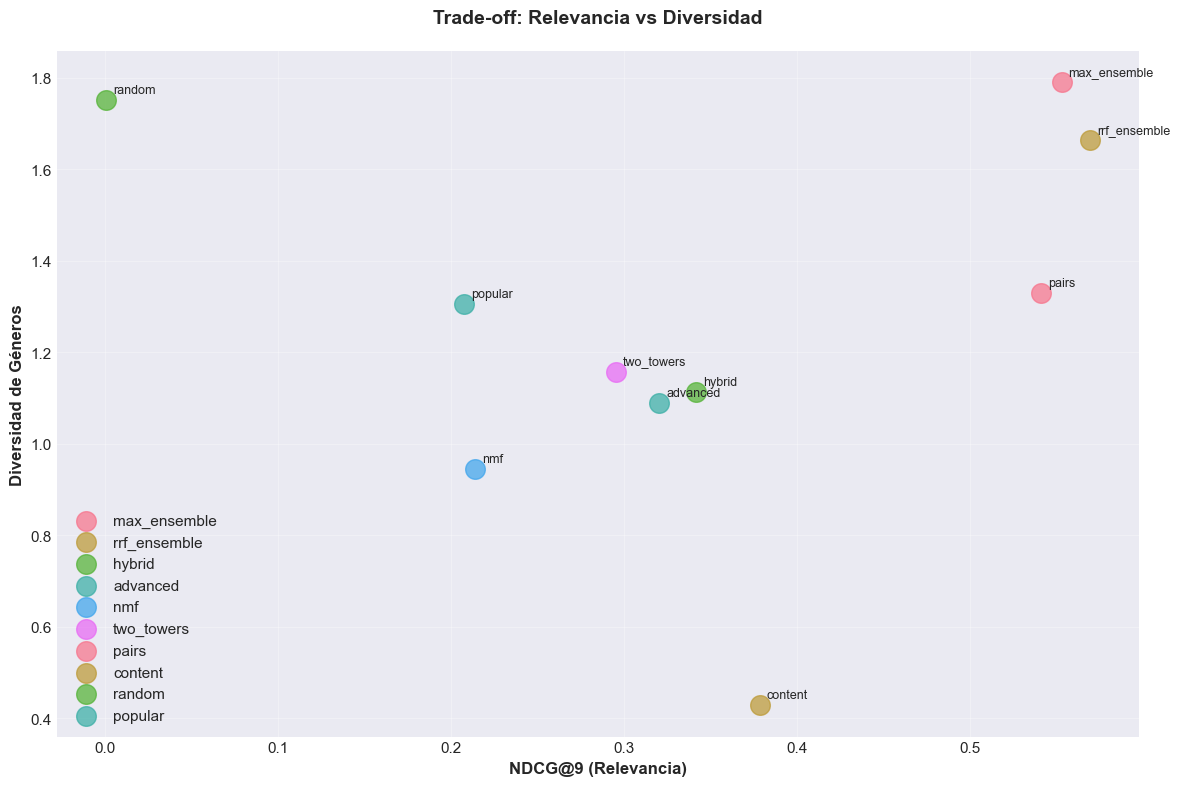

In [25]:
# Visualización 5: Trade-off entre relevancia y diversidad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    div_col = f"{strategy}_genre_diversity"

    if ndcg_col in df.columns and div_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_div = df[div_col].mean()
        ax.scatter(mean_ndcg, mean_div, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_div), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversidad de Géneros", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Diversidad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

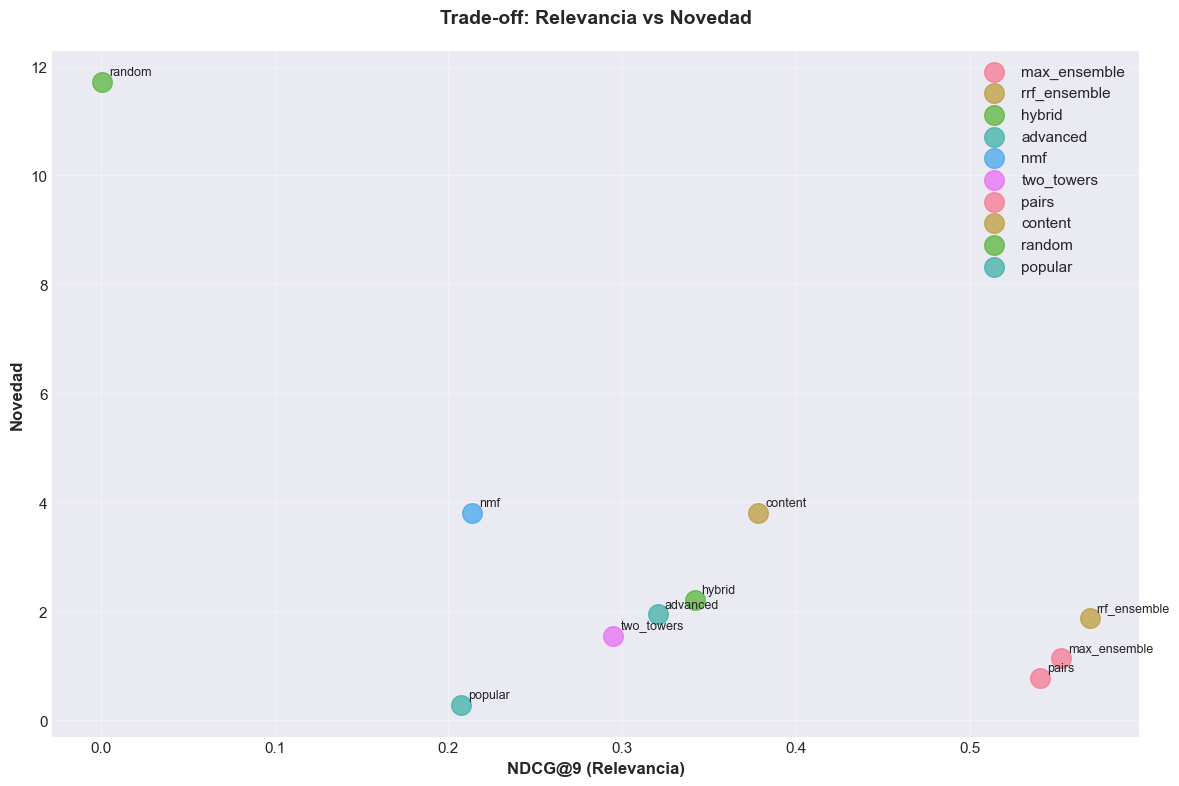

In [26]:
# Visualización 6: Trade-off entre relevancia y novedad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    nov_col = f"{strategy}_novelty"

    if ndcg_col in df.columns and nov_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_nov = df[nov_col].mean()
        ax.scatter(mean_ndcg, mean_nov, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_nov), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Novedad", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Novedad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

### Resumen de hallazgos actualizados

1. **RRF-Ensemble lidera en relevancia y ranking**: obtiene el mayor NDCG@9 (0.5692) y mejora MRR a 0.5350 (+0.043 vs max_ensemble), ganando el 37.7% de los enfrentamientos usuario a usuario frente al 34.6% de max_ensemble (27.8% empates). La ventaja promedio es modesta (+0.0164), pero suficiente para posicionarlo como nuevo ganador estable y estadísticamente significativa en NDCG/MRR (p < 0.01 en t-test y Wilcoxon).
2. **Max-Ensemble conserva la máxima precisión puntual**: alcanza Precision@9=0.2013, Recall@9=0.0682 y F1@9=0.0865, apenas por encima de rrf_ensemble (0.1976/0.0671/0.0848). Sigue siendo la opción preferida cuando se busca maximizar aciertos inmediatos sin priorizar exploración.
3. **Diversidad y novedad**: max_ensemble mantiene la mayor diversidad de géneros (1.79) y diversidad casi perfecta de artistas (0.9997). RRF reduce ~0.13 puntos en diversidad de géneros, pero incrementa la novedad promedio a 1.87 (+65% vs 1.14 de max), logrando más descubrimiento con mínima pérdida en precisión. `pairs` se sostiene como tercero en relevancia (NDCG 0.541) pero con novedad baja (0.77), mientras que `content` ofrece novedad alta (3.80) con relevancia moderada (0.379).
4. **Trade-offs principales**: RRF desplazó la frontera relevancia-novedad hacia arriba (más relevancia con más novedad). Max-Ensemble sigue a la cabeza en relevancia-diversidad; `pairs` y `content` marcan los extremos (alta relevancia/diversidad media vs relevancia media/diversidad baja). En precisión vs recall ambas variantes ensamble están balanceadas, mientras que `content` prioriza recall relativamente alto y `pairs` se mantiene competitivo en ambos.
5. **Análisis por tamaño de holdout**: con historiales ≤20 ítems max y RRF están prácticamente empatados (0.4655 vs 0.4627). Desde 21 ítems, RRF domina todos los segmentos (p.ej. 21-50: 0.625 vs 0.575; 51-100: 0.669 vs 0.652; 101-200: 0.740 vs 0.724). Para historiales >200, `pairs` sigue siendo tope (0.839) seguido por RRF (0.813) y Max (0.794), por lo que conviene combinar RRF con `pairs` para power users.

### Recomendaciones operativas

- **Sistema principal**: promover `rrf_ensemble` como configuración por defecto; maximiza relevancia agregada y ranking temprano (MRR) sin penalizar la precisión de forma significativa, además de aumentar novedad.
- **Fallback de alta precisión**: conservar `max_ensemble` como modo alterno cuando se necesite la precisión más alta posible (campañas críticas o slots limitados).
- **Segmentación por historial**: usar `rrf_ensemble` para usuarios nuevos/medios y escalar `pairs` para historiales >200 ítems, aprovechando el liderazgo de cada método en su nicho.
- **Exploración controlada**: combinar RRF con componentes de alto descubrimiento (`nmf`, `content`) cuando se necesiten catálogos más frescos, preservando el peso de Max para evitar caídas de relevancia.
- **Trabajo futuro**: ajustar los pesos de RRF por estrategia para recuperar la ligera caída en diversidad de géneros e instrumentar mediciones online que confirmen la ganancia observada offline.

COMPARACIÓN: MAX-ENSEMBLE vs RRF-ENSEMBLE

Métricas promedio:
----------------------------------------
  ndcg        : MAX=0.5528  RRF=0.5692  Diff=+0.0164 (RRF)
  precision   : MAX=0.2013  RRF=0.1976  Diff=-0.0037 (MAX)
  recall      : MAX=0.0682  RRF=0.0671  Diff=-0.0011 (MAX)
  f1          : MAX=0.0865  RRF=0.0848  Diff=-0.0017 (MAX)
  mrr         : MAX=0.4918  RRF=0.5350  Diff=+0.0433 (RRF)

Comparación directa (por usuario):
----------------------------------------
  Max gana:   579 usuarios (34.6%)
  RRF gana:   631 usuarios (37.7%)
  Empates:    465 usuarios (27.8%)

Distribución de diferencias (RRF - MAX):
----------------------------------------
  Media:   +0.0164
  Mediana: +0.0000
  Std:     0.2443
  Min:     -1.0000
  Max:     +1.0000


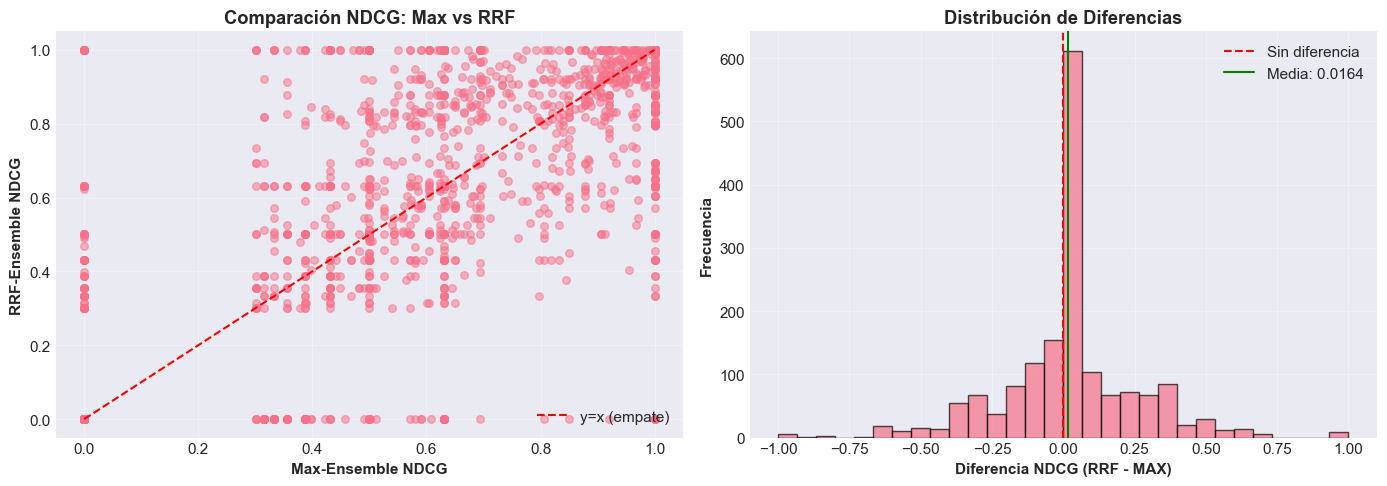

In [27]:
# Comparación directa: Max-Ensemble vs RRF-Ensemble
print("=" * 80)
print("COMPARACIÓN: MAX-ENSEMBLE vs RRF-ENSEMBLE")
print("=" * 80)

if "rrf_ensemble_ndcg" in df.columns and "max_ensemble_ndcg" in df.columns:
    # Comparación de métricas principales
    print("\nMétricas promedio:")
    print("-" * 40)
    for metric in ["ndcg", "precision", "recall", "f1", "mrr"]:
        max_col = f"max_ensemble_{metric}"
        rrf_col = f"rrf_ensemble_{metric}"
        if max_col in df.columns and rrf_col in df.columns:
            max_val = df[max_col].mean()
            rrf_val = df[rrf_col].mean()
            diff = rrf_val - max_val
            winner = "RRF" if diff > 0 else "MAX" if diff < 0 else "TIE"
            print(
                f"  {metric:12s}: MAX={max_val:.4f}  RRF={rrf_val:.4f}  Diff={diff:+.4f} ({winner})"
            )

    # Comparación head-to-head
    print("\nComparación directa (por usuario):")
    print("-" * 40)
    df["max_wins"] = df["max_ensemble_ndcg"] > df["rrf_ensemble_ndcg"]
    df["rrf_wins"] = df["rrf_ensemble_ndcg"] > df["max_ensemble_ndcg"]
    df["tie"] = df["max_ensemble_ndcg"] == df["rrf_ensemble_ndcg"]

    print(f"  Max gana:  {df['max_wins'].sum():4d} usuarios ({df['max_wins'].mean()*100:.1f}%)")
    print(f"  RRF gana:  {df['rrf_wins'].sum():4d} usuarios ({df['rrf_wins'].mean()*100:.1f}%)")
    print(f"  Empates:   {df['tie'].sum():4d} usuarios ({df['tie'].mean()*100:.1f}%)")

    # Análisis de diferencias
    print("\nDistribución de diferencias (RRF - MAX):")
    print("-" * 40)
    diff = df["rrf_ensemble_ndcg"] - df["max_ensemble_ndcg"]
    print(f"  Media:   {diff.mean():+.4f}")
    print(f"  Mediana: {diff.median():+.4f}")
    print(f"  Std:     {diff.std():.4f}")
    print(f"  Min:     {diff.min():+.4f}")
    print(f"  Max:     {diff.max():+.4f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    ax1 = axes[0]
    ax1.scatter(df["max_ensemble_ndcg"], df["rrf_ensemble_ndcg"], alpha=0.5, s=30)
    ax1.plot([0, 1], [0, 1], "r--", label="y=x (empate)")
    ax1.set_xlabel("Max-Ensemble NDCG", fontweight="bold")
    ax1.set_ylabel("RRF-Ensemble NDCG", fontweight="bold")
    ax1.set_title("Comparación NDCG: Max vs RRF", fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Histogram de diferencias
    ax2 = axes[1]
    ax2.hist(diff, bins=30, edgecolor="black", alpha=0.7)
    ax2.axvline(x=0, color="red", linestyle="--", label="Sin diferencia")
    ax2.axvline(x=diff.mean(), color="green", linestyle="-", label=f"Media: {diff.mean():.4f}")
    ax2.set_xlabel("Diferencia NDCG (RRF - MAX)", fontweight="bold")
    ax2.set_ylabel("Frecuencia", fontweight="bold")
    ax2.set_title("Distribución de Diferencias", fontweight="bold")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(
        "Columnas de rrf_ensemble no encontradas. Ejecuta la evaluación con la versión actualizada."
    )

In [28]:
# Pruebas estadísticas pareadas: RRF vs Max
metrics_to_compare = ["ndcg", "precision", "recall", "f1", "mrr"]
stat_rows = []

for metric in metrics_to_compare:
    rrf_col = f"rrf_ensemble_{metric}"
    max_col = f"max_ensemble_{metric}"
    if rrf_col not in df.columns or max_col not in df.columns:
        continue

    paired = df[[rrf_col, max_col]].dropna()
    if paired.empty:
        continue

    rrf_vals = paired[rrf_col].to_numpy()
    max_vals = paired[max_col].to_numpy()
    diff = rrf_vals - max_vals

    t_stat, t_p = stats.ttest_rel(rrf_vals, max_vals)
    w_stat, w_p = stats.wilcoxon(diff, zero_method="pratt", alternative="two-sided")

    mean_diff = diff.mean()
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    ci_low = mean_diff - 1.96 * se
    ci_high = mean_diff + 1.96 * se
    cohen_d = mean_diff / diff.std(ddof=1)

    stat_rows.append(
        {
            "metric": metric.upper(),
            "mean_diff": mean_diff,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "t_stat": t_stat,
            "t_p_value": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p_value": w_p,
            "cohen_d": cohen_d,
        }
    )

stats_df = pd.DataFrame(stat_rows).set_index("metric")
stats_df = stats_df[
    [
        "mean_diff",
        "ci_low",
        "ci_high",
        "t_stat",
        "t_p_value",
        "wilcoxon_stat",
        "wilcoxon_p_value",
        "cohen_d",
    ]
].applymap(lambda x: round(x, 4))

print("Resultados de pruebas pareadas (RRF - MAX):")
stats_df

Resultados de pruebas pareadas (RRF - MAX):


/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_61707/558632702.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ]].applymap(lambda x: round(x, 4))


,mean_diff,ci_low,ci_high,t_stat,t_p_value,wilcoxon_stat,wilcoxon_p_value,cohen_d
metric,,,,,,,,
NDCG,0.0164,0.0047,0.0281,2.7457,0.0061,602870.5,0.0222,0.0671
PRECISION,-0.0037,-0.0082,0.0008,-1.6160,0.1063,421478.5,0.0758,-0.0395
RECALL,-0.0011,-0.0030,0.0008,-1.1285,0.2593,424497.5,0.1102,-0.0276
F1,-0.0017,-0.0039,0.0006,-1.4759,0.1401,424308.0,0.1078,-0.0361
MRR,0.0433,0.0277,0.0588,5.4582,0.0000,453915.0,0.0001,0.1334


### Evidencia estadística (RRF vs Max)

- **NDCG@9**: diferencia promedio +0.016 (IC95% [0.005, 0.028]); t pareado = 2.75 (p = 0.006) y Wilcoxon = 6.03e5 (p = 0.022). La mejora es estadísticamente significativa, aunque con tamaño de efecto pequeño (d = 0.07).
- **MRR**: diferencia +0.043 (IC95% [0.028, 0.059]); t pareado = 5.46 (p < 1e-6) y Wilcoxon = 4.54e5 (p = 0.0001). Efecto pequeño-moderado (d = 0.13) pero claramente significativo.
- **Precision, Recall y F1**: las diferencias medias (-0.004, -0.001, -0.002) tienen intervalos de confianza que cruzan 0 y p-values > 0.07 en ambos tests, por lo que no se puede afirmar ventaja estadística para ninguna variante en estas métricas.

Conclusión: la superioridad de `rrf_ensemble` está respaldada estadísticamente solo en NDCG y MRR; el resto de las diferencias son consistentes con ruido. Estos resultados sugieren continuar la exploración offline incrementando capacidades de descubrimiento (para recuperar diversidad) y planificar una validación online enfocada en relevancia temprana.


In [29]:
# Guardar resumen en CSV
summary_df.to_csv("../resultados_evaluacion_resumen.csv")
print("Resumen guardado en: resultados_evaluacion_resumen.csv")

# Estadísticas adicionales
print("\n" + "=" * 80)
print("ESTADÍSTICAS ADICIONALES")
print("=" * 80)
print(f"\nTotal de usuarios evaluados: {len(df)}")
print(f"Tamaño promedio de holdout: {df['holdout_size'].mean():.1f}")
print(f"Tamaño mínimo de holdout: {df['holdout_size'].min()}")
print(f"Tamaño máximo de holdout: {df['holdout_size'].max()}")

# Usuarios con mejor rendimiento por estrategia
print("\n" + "=" * 80)
print("TOP 5 USUARIOS POR ESTRATEGIA (NDCG)")
print("=" * 80)
for strategy in ["max_ensemble", "rrf_ensemble", "pairs", "content"]:
    ndcg_col = f"{strategy}_ndcg"
    if ndcg_col in df.columns:
        top_users = df.nlargest(5, ndcg_col)[["user_id", "holdout_size", ndcg_col]]
        print(f"\n{strategy.upper()}:")
        print(top_users.to_string(index=False))

Resumen guardado en: resultados_evaluacion_resumen.csv

ESTADÍSTICAS ADICIONALES

Total de usuarios evaluados: 1675
Tamaño promedio de holdout: 59.8
Tamaño mínimo de holdout: 6
Tamaño máximo de holdout: 4425

TOP 5 USUARIOS POR ESTRATEGIA (NDCG)

MAX_ENSEMBLE:
      user_id  holdout_size  max_ensemble_ndcg
  DerekWarner            10                1.0
SmartWentCody            84                1.0
   freight254            18                1.0
  KrydePerson            20                1.0
      Liamsrt            10                1.0

RRF_ENSEMBLE:
    user_id  holdout_size  rrf_ensemble_ndcg
   in5anity             9                1.0
DerekWarner            10                1.0
CleftPalate           126                1.0
    raddlad            40                1.0
   popoe435            34                1.0

PAIRS:
    user_id  holdout_size  pairs_ndcg
KyussMyTool           199         1.0
   lebeau42            12         1.0
DerekWarner            10         1.0
     Moraff 